In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bm25 = pd.read_csv("bm25_eval.csv")

In [3]:
bm25.head()

,company,k,hit_at_k,mrr_at_k
0,PT AKR Corporindo Tbk,5,0.392157,0.207843
1,PT AKR Corporindo Tbk,10,0.568627,0.230851
2,PT AKR Corporindo Tbk,20,0.686275,0.240118
3,PT Bank CIMB Niaga Tbk,5,0.612903,0.495699
4,PT Bank CIMB Niaga Tbk,10,0.645161,0.499731


In [4]:
bm25.count()

,0
company,30
k,30
hit_at_k,30
mrr_at_k,30


In [5]:
ret = pd.read_csv("retriever_eval.csv")

In [6]:
ret.head()

,company,k,hit_at_k,mrr_at_k
0,PT AKR Corporindo Tbk,5,0.607843,0.460458
1,PT AKR Corporindo Tbk,10,0.686275,0.471973
2,PT AKR Corporindo Tbk,20,0.843137,0.481796
3,PT Bank CIMB Niaga Tbk,5,0.741935,0.639785
4,PT Bank CIMB Niaga Tbk,10,0.935484,0.666923


In [7]:
ret.count()

,0
company,30
k,30
hit_at_k,30
mrr_at_k,30


In [8]:
rer = pd.read_csv("reranker_eval.csv")

In [9]:
rer.head()

,company,k,hit_at_k,mrr_at_k
0,PT AKR Corporindo Tbk,5,0.607843,0.381699
1,PT AKR Corporindo Tbk,10,0.705882,0.396639
2,PT AKR Corporindo Tbk,20,0.803922,0.403782
3,PT Bank CIMB Niaga Tbk,5,0.870968,0.708065
4,PT Bank CIMB Niaga Tbk,10,0.903226,0.712097


In [10]:
rer.count()

,0
company,30
k,30
hit_at_k,30
mrr_at_k,30


# Merge, Drop, and Rename

In [11]:
df_merged = (
        bm25
        .merge(ret, left_index=True, right_index=True, how='left')
        .merge(rer, left_index=True, right_index=True, how='left')
    )

In [12]:
df_merged.head(30)

,company_x,k_x,hit_at_k_x,mrr_at_k_x,company_y,k_y,hit_at_k_y,mrr_at_k_y,company,k,hit_at_k,mrr_at_k
0,PT AKR Corporindo Tbk,5,0.392157,0.207843,PT AKR Corporindo Tbk,5,0.607843,0.460458,PT AKR Corporindo Tbk,5,0.607843,0.381699
1,PT AKR Corporindo Tbk,10,0.568627,0.230851,PT AKR Corporindo Tbk,10,0.686275,0.471973,PT AKR Corporindo Tbk,10,0.705882,0.396639
2,PT AKR Corporindo Tbk,20,0.686275,0.240118,PT AKR Corporindo Tbk,20,0.843137,0.481796,PT AKR Corporindo Tbk,20,0.803922,0.403782
3,PT Bank CIMB Niaga Tbk,5,0.612903,0.495699,PT Bank CIMB Niaga Tbk,5,0.741935,0.639785,PT Bank CIMB Niaga Tbk,5,0.870968,0.708065
4,PT Bank CIMB Niaga Tbk,10,0.645161,0.499731,PT Bank CIMB Niaga Tbk,10,0.935484,0.666923,PT Bank CIMB Niaga Tbk,10,0.903226,0.712097
5,PT Bank CIMB Niaga Tbk,20,0.774194,0.507328,PT Bank CIMB Niaga Tbk,20,0.967742,0.669073,PT Bank CIMB Niaga Tbk,20,0.967742,0.716935
6,PT Bank Central Asia Tbk,5,0.508475,0.336723,PT Bank Central Asia Tbk,5,0.728814,0.481073,PT Bank Central Asia Tbk,5,0.779661,0.530508
7,PT Bank Central Asia Tbk,10,0.677966,0.359430,PT Bank Central Asia Tbk,10,0.762712,0.485593,PT Bank Central Asia Tbk,10,0.881356,0.543873
8,PT Bank Central Asia Tbk,20,0.779661,0.366634,PT Bank Central Asia Tbk,20,0.864407,0.492518,PT Bank Central Asia Tbk,20,0.949153,0.549232
9,PT Bank Jago Tbk,5,0.454545,0.251818,PT Bank Jago Tbk,5,0.654545,0.417879,PT Bank Jago Tbk,5,0.727273,0.487273


In [13]:
df_merged = df_merged.drop(columns=['company', 'k', 'company_y', 'k_y'])

In [14]:
df_merged = df_merged.rename(columns={
    "company_x": "company",
    "k_x": "k",
    "hit_at_k_x": "hit_at_k_sparse",
    "mrr_at_k_x": "mrr_at_k_sparse",
    "hit_at_k_y": "hit_at_k_dense",
    "mrr_at_k_y": "mrr_at_k_dense",
    "hit_at_k": "hit_at_k_rerank",
    "mrr_at_k": "mrr_at_k_rerank",
})

In [15]:
df_merged.head()

,company,k,hit_at_k_sparse,mrr_at_k_sparse,hit_at_k_dense,mrr_at_k_dense,hit_at_k_rerank,mrr_at_k_rerank
0,PT AKR Corporindo Tbk,5,0.392157,0.207843,0.607843,0.460458,0.607843,0.381699
1,PT AKR Corporindo Tbk,10,0.568627,0.230851,0.686275,0.471973,0.705882,0.396639
2,PT AKR Corporindo Tbk,20,0.686275,0.240118,0.843137,0.481796,0.803922,0.403782
3,PT Bank CIMB Niaga Tbk,5,0.612903,0.495699,0.741935,0.639785,0.870968,0.708065
4,PT Bank CIMB Niaga Tbk,10,0.645161,0.499731,0.935484,0.666923,0.903226,0.712097


In [16]:
df_merged.to_csv("eval_merged.csv")

# Eval per K

In [17]:
eval_per_k = (
    df_merged
    .groupby("k")
    .agg(
        hit_sparse_mean=("hit_at_k_sparse", "mean"),
        hit_dense_mean=("hit_at_k_dense", "mean"),
        hit_rank_mean=("hit_at_k_rerank", "mean"),
        mrr_sparse_mean=("mrr_at_k_sparse", "mean"),
        mrr_dense_mean=("mrr_at_k_dense", "mean"),
        mrr_rank_mean=("mrr_at_k_rerank", "mean"),
    )
    .reset_index()
)

In [18]:
eval_per_k.head()

,k,hit_sparse_mean,hit_dense_mean,hit_rank_mean,mrr_sparse_mean,mrr_dense_mean,mrr_rank_mean
0,5,0.526743,0.765515,0.803842,0.355630,0.582110,0.580004
1,10,0.642821,0.859234,0.876757,0.370566,0.594859,0.589687
2,20,0.778461,0.933131,0.937619,0.380041,0.599972,0.594014


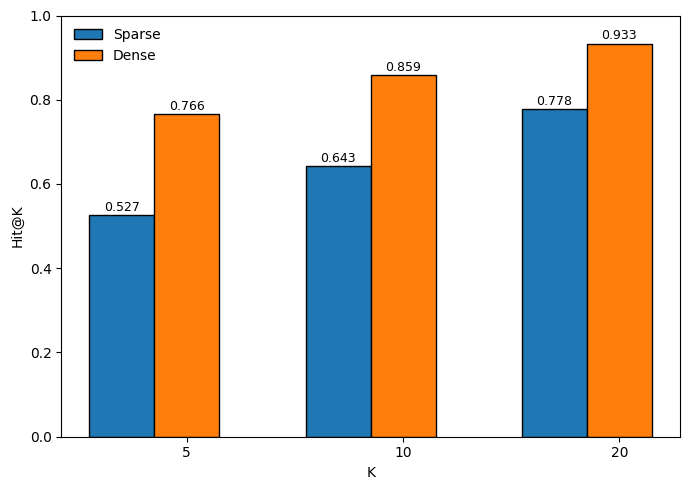

In [19]:
hit_per_k = np.arange(len(eval_per_k["k"]))
width = 0.3

plt.figure(figsize=(7, 5))

bars1 = plt.bar(hit_per_k - width, eval_per_k["hit_sparse_mean"],
                width, label="Sparse", edgecolor="black")

bars2 = plt.bar(hit_per_k, eval_per_k["hit_dense_mean"],
                width, label="Dense", edgecolor="black")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

min_val = np.min(np.concatenate([
    eval_per_k["hit_sparse_mean"],
    eval_per_k["hit_dense_mean"],
]))

max_val = np.max(np.concatenate([
    eval_per_k["hit_sparse_mean"],
    eval_per_k["hit_dense_mean"],
]))

plt.ylim(0,1)

plt.xlabel("K")
plt.ylabel("Hit@K")
plt.xticks(hit_per_k, eval_per_k["k"])
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

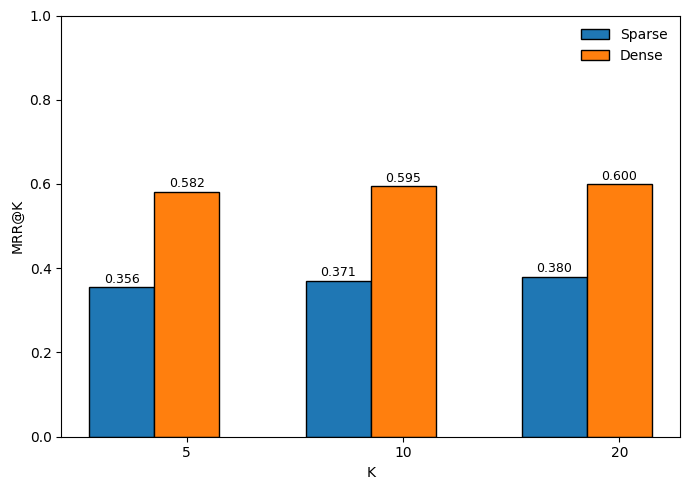

In [20]:
mrr_per_k = np.arange(len(eval_per_k["k"]))
width = 0.3

plt.figure(figsize=(7, 5))


bars1 = plt.bar(mrr_per_k - width, eval_per_k["mrr_sparse_mean"],
                width, label="Sparse", edgecolor="black", color="#1f77b4")

bars2 = plt.bar(mrr_per_k, eval_per_k["mrr_dense_mean"],
                width, label="Dense", edgecolor="black", color="#ff7f0e")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

min_val = np.min(np.concatenate([
    eval_per_k["mrr_sparse_mean"],
    eval_per_k["mrr_dense_mean"],
]))

max_val = np.max(np.concatenate([
    eval_per_k["mrr_sparse_mean"],
    eval_per_k["mrr_dense_mean"],
]))

plt.ylim(0, 1)

plt.xlabel("K")
plt.ylabel("MRR@K")
plt.xticks(mrr_per_k, eval_per_k["k"])
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

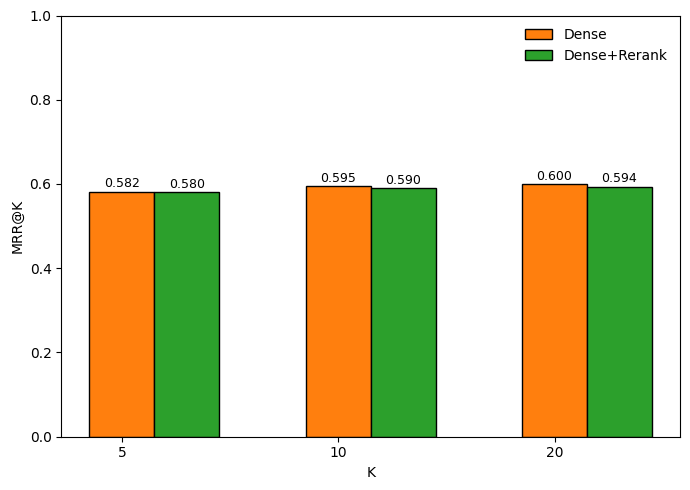

In [21]:
mrr_per_k = np.arange(len(eval_per_k["k"]))
width = 0.3

plt.figure(figsize=(7, 5))

bars2 = plt.bar(mrr_per_k, eval_per_k["mrr_dense_mean"],
                width, label="Dense", edgecolor="black", color="#ff7f0e")

bars3 = plt.bar(mrr_per_k + width, eval_per_k["mrr_rank_mean"],
                width, label="Dense+Rerank", edgecolor="black", color="#2ca02c")

for bars in [bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

min_val = np.min(np.concatenate([
    eval_per_k["mrr_dense_mean"],
    eval_per_k["mrr_rank_mean"],
]))

max_val = np.max(np.concatenate([
    eval_per_k["mrr_dense_mean"],
    eval_per_k["mrr_rank_mean"],
]))

plt.ylim(0, 1)

plt.xlabel("K")
plt.ylabel("MRR@K")
plt.xticks(mrr_per_k, eval_per_k["k"])
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

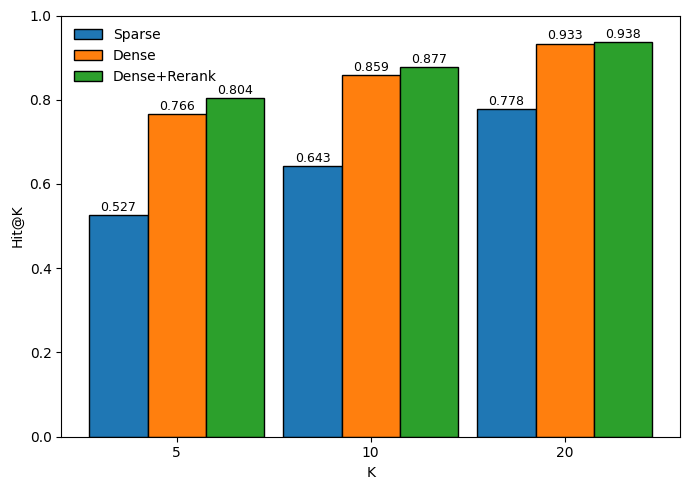

In [22]:
hit_per_k = np.arange(len(eval_per_k["k"]))
width = 0.3

plt.figure(figsize=(7, 5))

bars1 = plt.bar(hit_per_k - width, eval_per_k["hit_sparse_mean"],
                width, label="Sparse", edgecolor="black")

bars2 = plt.bar(hit_per_k, eval_per_k["hit_dense_mean"],
                width, label="Dense", edgecolor="black")

bars3 = plt.bar(hit_per_k + width, eval_per_k["hit_rank_mean"],
                width, label="Dense+Rerank", edgecolor="black")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

min_val = np.min(np.concatenate([
    eval_per_k["hit_sparse_mean"],
    eval_per_k["hit_dense_mean"],
    eval_per_k["hit_rank_mean"],
]))

max_val = np.max(np.concatenate([
    eval_per_k["hit_sparse_mean"],
    eval_per_k["hit_dense_mean"],
    eval_per_k["hit_rank_mean"],
]))

plt.ylim(0, 1)

plt.xlabel("K")
plt.ylabel("Hit@K")
plt.xticks(hit_per_k, eval_per_k["k"])
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

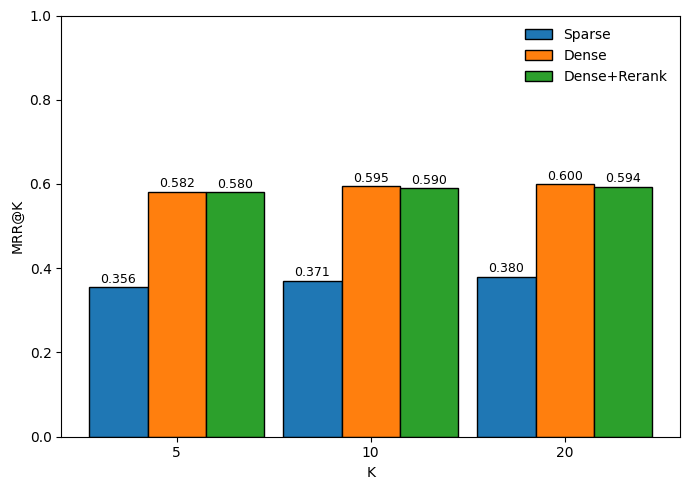

In [23]:
mrr_per_k = np.arange(len(eval_per_k["k"]))
width = 0.3

plt.figure(figsize=(7, 5))


bars1 = plt.bar(mrr_per_k - width, eval_per_k["mrr_sparse_mean"],
                width, label="Sparse", edgecolor="black", color="#1f77b4")

bars2 = plt.bar(mrr_per_k, eval_per_k["mrr_dense_mean"],
                width, label="Dense", edgecolor="black", color="#ff7f0e")

bars3 = plt.bar(mrr_per_k + width, eval_per_k["mrr_rank_mean"],
                width, label="Dense+Rerank", edgecolor="black", color="#2ca02c")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

min_val = np.min(np.concatenate([
    eval_per_k["mrr_sparse_mean"],
    eval_per_k["mrr_dense_mean"],
    eval_per_k["mrr_rank_mean"],
]))

max_val = np.max(np.concatenate([
    eval_per_k["mrr_sparse_mean"],
    eval_per_k["mrr_dense_mean"],
    eval_per_k["mrr_rank_mean"],
]))

plt.ylim(0, 1)

plt.xlabel("K")
plt.ylabel("MRR@K")
plt.xticks(mrr_per_k, eval_per_k["k"])
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

# Eval per Company on K=10

In [24]:
eval_per_company = df_merged[df_merged['k'] == 10].reset_index(drop=True)

In [25]:
eval_per_company = eval_per_company.rename(columns={
    "hit_at_k_sparse": "hit_at_10_sparse",
    "mrr_at_k_sparse": "mrr_at_10_sparse",
    "hit_at_k_dense": "hit_at_10_dense",
    "mrr_at_k_dense": "mrr_at_10_dense",
    "hit_at_k_rerank": "hit_at_10_rerank",
    "mrr_at_k_rerank": "mrr_at_10_rerank",
})

In [26]:
eval_per_company.head()

,company,k,hit_at_10_sparse,mrr_at_10_sparse,hit_at_10_dense,mrr_at_10_dense,hit_at_10_rerank,mrr_at_10_rerank
0,PT AKR Corporindo Tbk,10,0.568627,0.230851,0.686275,0.471973,0.705882,0.396639
1,PT Bank CIMB Niaga Tbk,10,0.645161,0.499731,0.935484,0.666923,0.903226,0.712097
2,PT Bank Central Asia Tbk,10,0.677966,0.359430,0.762712,0.485593,0.881356,0.543873
3,PT Bank Jago Tbk,10,0.636364,0.273709,0.763636,0.432648,0.781818,0.494488
4,PT Bank Mandiri Tbk,10,0.732143,0.413315,0.928571,0.766093,0.982143,0.691667


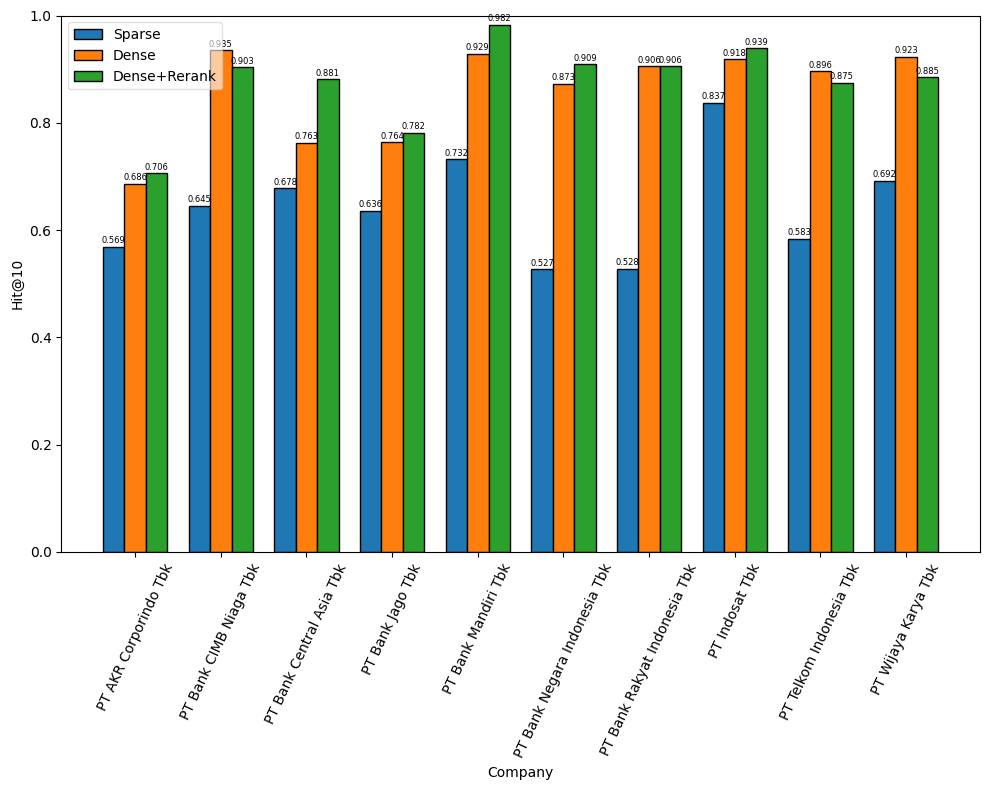

In [27]:
hit_per_k = np.arange(len(eval_per_company["company"])) * 2
width = 0.5

plt.figure(figsize=(10, 8))

bars1 = plt.bar(hit_per_k - width, eval_per_company["hit_at_10_sparse"],
                width, label="Sparse", edgecolor="black")

bars2 = plt.bar(hit_per_k, eval_per_company["hit_at_10_dense"],
                width, label="Dense", edgecolor="black")

bars3 = plt.bar(hit_per_k + width, eval_per_company["hit_at_10_rerank"],
                width, label="Dense+Rerank", edgecolor="black")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=6
        )

min_val = np.min(np.concatenate([
    eval_per_company["hit_at_10_sparse"],
    eval_per_company["hit_at_10_dense"],
    eval_per_company["hit_at_10_rerank"]
]))

max_val = np.max(np.concatenate([
    eval_per_company["hit_at_10_sparse"],
    eval_per_company["hit_at_10_dense"],
    eval_per_company["hit_at_10_rerank"]
]))

plt.ylim(0, 1)

plt.xlabel("Company")
plt.ylabel("Hit@10")
plt.xticks(hit_per_k, eval_per_company["company"], rotation=65)
plt.legend(framealpha=0.6)

plt.tight_layout()
plt.show()

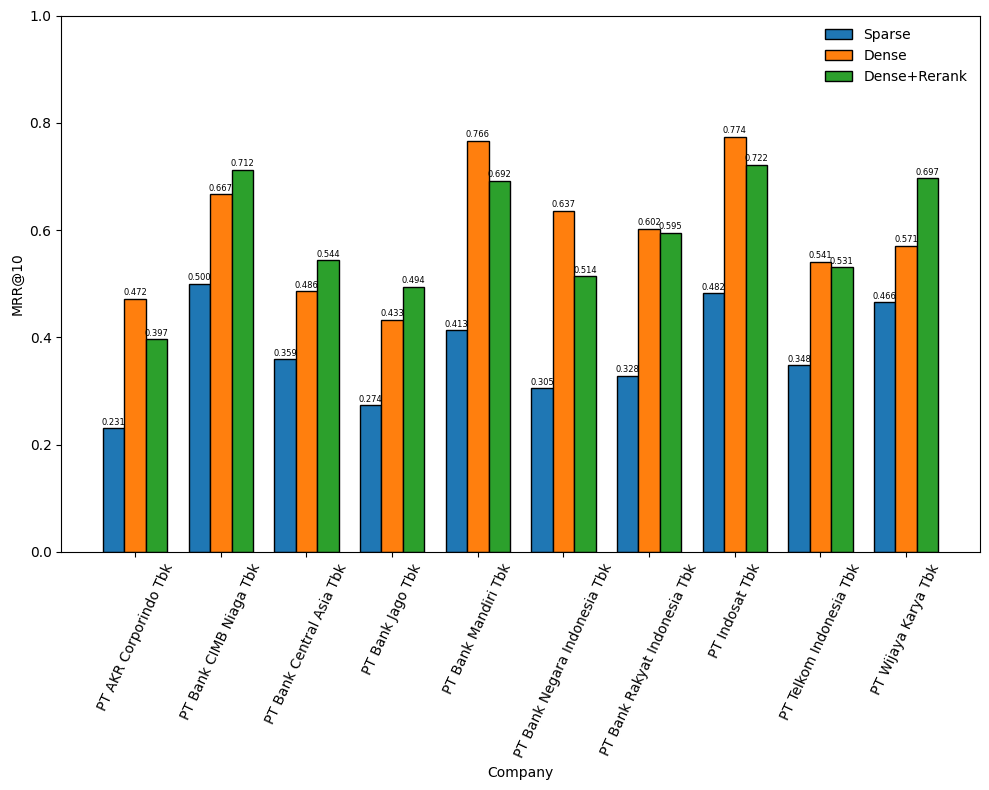

In [28]:
mrr_per_k = np.arange(len(eval_per_company["company"])) * 2
width = 0.5

plt.figure(figsize=(10, 8))

bars1 = plt.bar(mrr_per_k - width, eval_per_company["mrr_at_10_sparse"],
                width, label="Sparse", edgecolor="black")

bars2 = plt.bar(mrr_per_k, eval_per_company["mrr_at_10_dense"],
                width, label="Dense", edgecolor="black")

bars3 = plt.bar(mrr_per_k + width, eval_per_company["mrr_at_10_rerank"],
                width, label="Dense+Rerank", edgecolor="black")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=6
        )

min_val = np.min(np.concatenate([
    eval_per_company["mrr_at_10_sparse"],
    eval_per_company["mrr_at_10_dense"],
    eval_per_company["mrr_at_10_rerank"]
]))

max_val = np.max(np.concatenate([
    eval_per_company["mrr_at_10_sparse"],
    eval_per_company["mrr_at_10_dense"],
    eval_per_company["mrr_at_10_rerank"]
]))

plt.ylim(0, 1)

plt.xlabel("Company")
plt.ylabel("MRR@10")
plt.xticks(mrr_per_k, eval_per_company["company"], rotation=65)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()